# Fake Reviews Detection - Complete Analysis

This notebook provides a comprehensive analysis for detecting fake reviews using various machine learning algorithms. We'll use text preprocessing, feature extraction, and multiple classification models to identify fake reviews.

## Table of Contents
1. **Import Libraries and Setup**
2. **Data Loading and Exploration**
3. **Data Preprocessing and Cleaning**
4. **Exploratory Data Analysis (EDA)**
5. **Text Processing and Feature Engineering**
6. **Model Training and Evaluation**
7. **Model Comparison and Results**
8. **Pipeline Approach with TF-IDF**
9. **Model Saving and Conclusion**
10. **Final Results Summary**

# 1. Import Libraries and Setup
Import all necessary libraries for data processing, visualization, and machine learning.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import pickle
import os
from collections import Counter

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Natural Language Processing
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Download required NLTK data
nltk.download('stopwords', quiet=True)

# Settings
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.ensemble import RandomForestClassifier
# import naive bayes custom model
import sys
sys.path.append("../models/")
from naive_bayes import NaiveBayes, GaussianNaiveBayes, MultinomialNaiveBayes, BernoulliNaiveBayes
# Set style for better visualization
sns.set_style("whitegrid")
plt.style.use('default')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# 2. Data Loading and Exploration
Load the preprocessed dataset and perform initial exploration.

In [2]:
# Load the dataset
dataset_path = "Preprocessed Fake Reviews Detection Dataset.csv"
df = pd.read_csv(dataset_path)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
Dataset shape: (40432, 5)

First 5 rows:


,Unnamed: 0,category,rating,label,text_
0,0,Home_and_Kitchen_5,5.0,CG,love well made sturdi comfort i love veri pretti
1,1,Home_and_Kitchen_5,5.0,CG,love great upgrad origin i 've mine coupl year
2,2,Home_and_Kitchen_5,5.0,CG,thi pillow save back i love look feel pillow
3,3,Home_and_Kitchen_5,1.0,CG,miss inform use great product price i
4,4,Home_and_Kitchen_5,5.0,CG,veri nice set good qualiti we set two month


In [3]:
# Basic information about the dataset
print("Dataset Information:")
print("=" * 50)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  40432 non-null  int64  
 1   category    40432 non-null  object 
 2   rating      40432 non-null  float64
 3   label       40432 non-null  object 
 4   text_       40431 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.5+ MB


In [4]:
# Check for missing values and duplicates
print("Missing Values Analysis:")
print("=" * 30)
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing Values Analysis:
Missing values per column:
Unnamed: 0    0
category      0
rating        0
label         0
text_         1
dtype: int64

Total missing values: 1
Duplicate rows: 0


# 3. Data Preprocessing and Cleaning
Clean the data and prepare it for analysis.

In [5]:
# Clean the data
# Remove unnamed columns if exists
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
    print("✓ Removed 'Unnamed: 0' column")

# Remove any remaining missing values
initial_shape = df.shape
df.dropna(inplace=True)
print(f"✓ Removed {initial_shape[0] - df.shape[0]} rows with missing values")

# Add text length feature for analysis
df['text_length'] = df['text_'].apply(len)
print("✓ Added text_length feature")

print("\nData cleaning completed!")
print(f"Final dataset shape: {df.shape}")
df.head()

✓ Removed 'Unnamed: 0' column
✓ Removed 1 rows with missing values
✓ Added text_length feature

Data cleaning completed!
Final dataset shape: (40431, 5)


,category,rating,label,text_,text_length
0,Home_and_Kitchen_5,5.0,CG,love well made sturdi comfort i love veri pretti,48
1,Home_and_Kitchen_5,5.0,CG,love great upgrad origin i 've mine coupl year,46
2,Home_and_Kitchen_5,5.0,CG,thi pillow save back i love look feel pillow,44
3,Home_and_Kitchen_5,1.0,CG,miss inform use great product price i,37
4,Home_and_Kitchen_5,5.0,CG,veri nice set good qualiti we set two month,43


In [6]:
# Display basic statistics
print("Dataset Statistics:")
print("=" * 30)
df.describe(include='all').T

Dataset Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
category,40431,10,Kindle_Store_5,4730,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,40431.0,NaN,NaN,NaN,4.256585,1.144367,1.0,4.0,5.0,5.0,5.0
label,40431,2,OR,20216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text_,40431,40387,my dog love kept occupi long time she chase,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text_length,40431.0,NaN,NaN,NaN,205.767109,219.422327,8.0,64.0,116.0,253.0,2232.0


# 4. Exploratory Data Analysis (EDA)
Analyze the distribution of labels and text characteristics.

In [7]:
# Analyze label distribution
print("Label Distribution:")
print("=" * 20)
label_counts = df['label'].value_counts()
print(label_counts)
print(f"\nLabel proportions:")
print(df['label'].value_counts(normalize=True).round(4))

Label Distribution:
label
OR    20216
CG    20215
Name: count, dtype: int64

Label proportions:
label
OR    0.5
CG    0.5
Name: proportion, dtype: float64


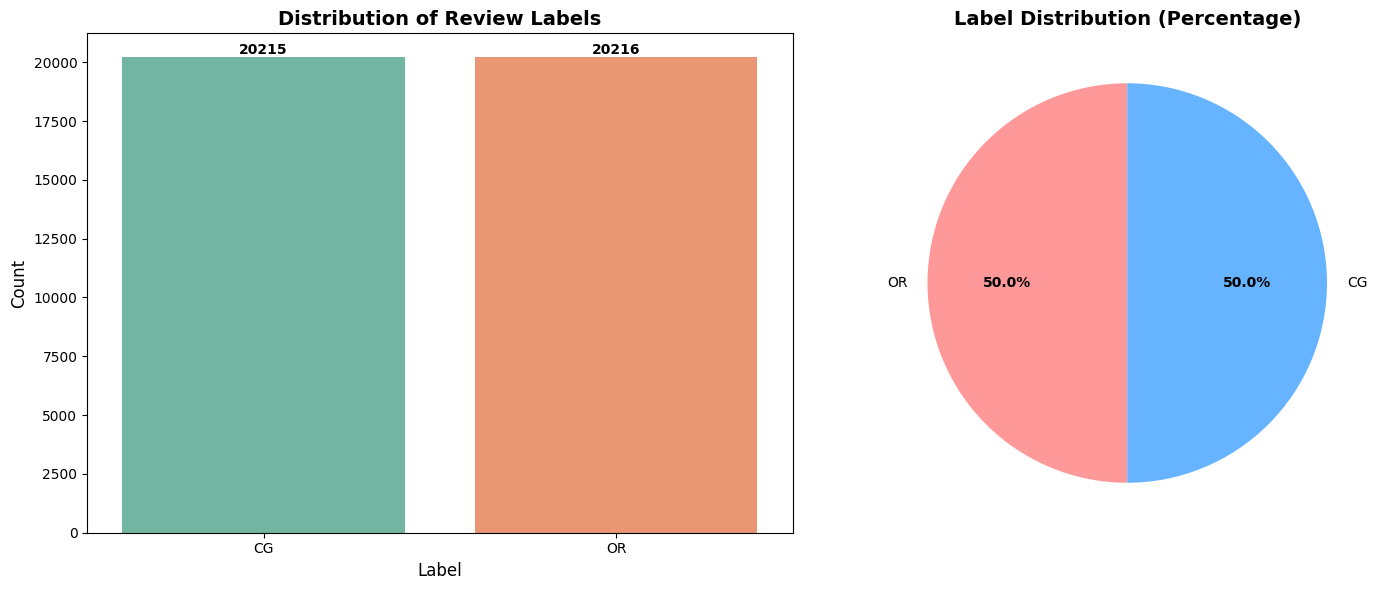

In [8]:
# Visualize label distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot
sns.countplot(data=df, x='label', palette='Set2', ax=ax1)
ax1.set_title('Distribution of Review Labels', fontsize=14, fontweight='bold')
ax1.set_xlabel('Label', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)

# Add count labels on bars
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')

# Pie chart
colors = ['#FF9999', '#66B3FF']
wedges, texts, autotexts = ax2.pie(label_counts.values, labels=label_counts.index, 
                                  colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Label Distribution (Percentage)', fontsize=14, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

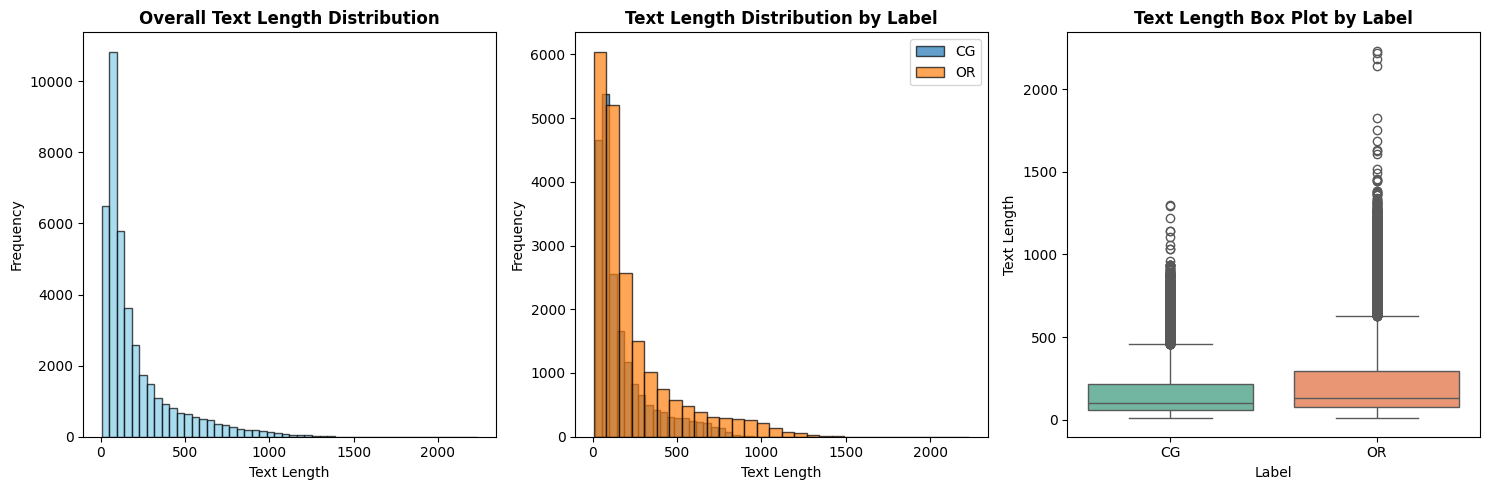

In [9]:
# Analyze text length distribution
plt.figure(figsize=(15, 5))

# Overall text length distribution
plt.subplot(1, 3, 1)
plt.hist(df['text_length'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Overall Text Length Distribution', fontweight='bold')
plt.xlabel('Text Length')
plt.ylabel('Frequency')

# Text length by label
plt.subplot(1, 3, 2)
for label in df['label'].unique():
    subset = df[df['label'] == label]['text_length']
    plt.hist(subset, bins=30, alpha=0.7, label=f'{label}', edgecolor='black')
plt.title('Text Length Distribution by Label', fontweight='bold')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.legend()

# Box plot for text length by label
plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='label', y='text_length', palette='Set2')
plt.title('Text Length Box Plot by Label', fontweight='bold')
plt.xlabel('Label')
plt.ylabel('Text Length')

plt.tight_layout()
plt.show()

In [10]:
# Statistical summary by label
print("Text Length Statistics by Label:")
print("=" * 35)
text_stats = df.groupby('label')['text_length'].describe()
print(text_stats)

Text Length Statistics by Label:
         count        mean         std   min   25%    50%    75%     max
label                                                                   
CG     20215.0  173.639030  173.955252  13.0  57.0   99.0  217.0  1300.0
OR     20216.0  237.893599  252.920950   8.0  74.0  134.0  296.0  2232.0


In [11]:
# # 11. Clustering Analysis với K-Means và C-Means
# print("🔍 PHÂN TÍCH CLUSTERING VỚI K-MEANS VÀ C-MEANS")
# print("=" * 60)

# # Chuẩn bị dữ liệu cho clustering
# print("1. Chuẩn bị dữ liệu cho clustering...")

# # Sử dụng bag of words custom để tạo features
# bow_vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
# X_bow = bow_vectorizer.fit_transform(df['text_'])
# # Chuyển đổi thành TF-IDF
# tfidf_transformer = TfidfTransformer()
# X_tfidf = tfidf_transformer.fit_transform(X_bow)
# # Giảm chiều dữ liệu với PCA để clustering hiệu quả hơn
# svd = TruncatedSVD(n_components=500, random_state=42)
# X_svd = svd.fit_transform(X_tfidf)

# print(f"✓ TF-IDF features: {X_tfidf.shape}")
# print(f"✓ SVD reduced features: {X_svd.shape}")
# # print(f"✓ Explained variance ratio: {X_svd.explained_variance_ratio_.sum():.3f}")

# 5. Text Processing and Feature Engineering
Process the text data and create features for machine learning.

In [12]:
# Define text preprocessing function
def text_process(text):
    """
    Process text by:
    1. Removing punctuation
    2. Converting to lowercase
    3. Removing stopwords
    4. Tokenizing
    """
    # Remove punctuation and convert to lowercase
    # 1. Loại bỏ dấu câu
    nopunc = [char for char in text if char not in string.punctuation]
    nopunc = ''.join(nopunc).lower()
    # 2. Loại bỏ stopwords và tokenize
    # Remove stopwords and tokenize
    return [word for word in nopunc.split()
     if word not in stopwords.words('english')]

# Test the function
sample_text = df['text_'].iloc[0]
print("Original text sample:")
print(sample_text[:200] + "...")
print("\nProcessed text sample:")
print(text_process(sample_text)[:20])

Original text sample:
love well made sturdi comfort i love veri pretti...

Processed text sample:
['love', 'well', 'made', 'sturdi', 'comfort', 'love', 'veri', 'pretti']


In [13]:
# Alternative preprocessing using NLTK stemming (similar to spam detection approach)
ps = PorterStemmer()
corpus = []

# Get stopwords but keep 'not' as it's important for sentiment
# Loại bỏ 'not' khỏi stopwords (quan trọng cho sentiment)
all_stop_words = set(stopwords.words('english'))
all_stop_words.remove('not')

print("Processing text data...")
for i in range(len(df)):
    # Convert to lowercase, remove punctuation, and split
    # 1. Chuyển về chữ thường và loại dấu câu
    text = df['text_'].iloc[i].lower().translate(str.maketrans('', '', string.punctuation)).split()
    
    # Apply stemming and remove stopwords
    # 2. Áp dụng stemming và loại stopwords
    text = [ps.stem(word) for word in text if word not in all_stop_words]
    text = ' '.join(text)
    corpus.append(text)

print(f"Text processing completed for {len(corpus)} reviews!")

# Show example of processed text
print("\nExample of processed text:")
print("Original:", df['text_'].iloc[0][:100] + "...")
print("Processed:", corpus[0][:100] + "...")

Processing text data...
Text processing completed for 40431 reviews!

Example of processed text:
Original: love well made sturdi comfort i love veri pretti...
Processed: love well made sturdi comfort love veri pretti...


In [14]:
# Analyze most common words in the corpus
# Top 20 từ phổ biến nhất
print("Most Common Words in Processed Corpus:")
print("=" * 40)
most_common = Counter(' '.join(corpus).split()).most_common(20)
for word, count in most_common:
    print(f"{word:15} : {count}")
# love: 19,088 lần
# book: 17,351 lần  
# great: 16,641 lần
# nt: 15,001 lần (viết tắt của "not")

Most Common Words in Processed Corpus:


love            : 19088
book            : 17351
great           : 16641
nt              : 15001
one             : 14633
good            : 14286
like            : 12755
use             : 12640
read            : 11578
thi             : 11518
would           : 10770
stori           : 10334
well            : 10308
work            : 8415
get             : 8374
littl           : 8150
charact         : 7158
recommend       : 6622
look            : 6557
time            : 6384


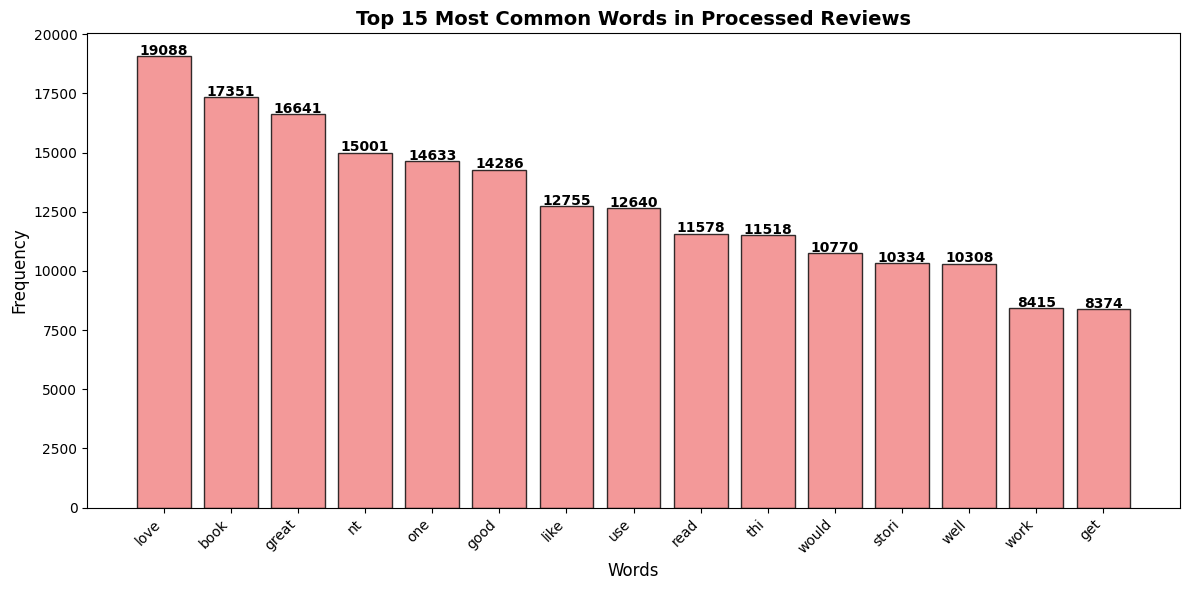

In [15]:
# Visualize most common words
words, counts = zip(*Counter(' '.join(corpus).split()).most_common(15))

plt.figure(figsize=(12, 6))
bars = plt.bar(words, counts, color='lightcoral', edgecolor='black', alpha=0.8)
plt.title('Top 15 Most Common Words in Processed Reviews', fontsize=14, fontweight='bold')
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(bar.get_height())}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 6. Model Training and Evaluation
Create and train multiple machine learning models for comparison.

In [ ]:
# Create Bag of Words model
# Tạo Bag of Words với 5000 features
# Chuyển đổi corpus (tập hợp các văn bản đã được xử lý) thành feature matrix dạng số để train model
print("Creating Bag of Words features...")
cv = CountVectorizer(max_features=5000)  # Limit features for efficiency
X = cv.fit_transform(corpus).toarray()
# Kết quả: Matrix X với mỗi hàng = 1 review, mỗi cột = 1 từ vựng
y = df['label']

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"Feature matrix sparsity: {np.round((np.count_nonzero(X) / X.size) * 100, 2)}%")
# Kết quả: Matrix 40,431 x 5,000 (sparsity: 0.47% cells có giá trị khác 0)

Creating Bag of Words features...
Feature matrix shape: (40431, 5000)
Target variable shape: (40431,)
Feature matrix sparsity: 0.47%


In [34]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Training: 32,344 samples
# Test: 8,087 samples
print("Data split completed:")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print("\nLabel distribution in training set:")
print(pd.Series(y_train).value_counts())
print("\nLabel distribution in test set:")
print(pd.Series(y_test).value_counts())
print(pd.Series(y_test).head(10))

Data split completed:
Training set: (32344, 5000)
Test set: (8087, 5000)

Label distribution in training set:
label
OR    16172
CG    16172
Name: count, dtype: int64

Label distribution in test set:
label
OR    4044
CG    4043
Name: count, dtype: int64
33059    OR
19482    CG
38225    OR
29368    CG
8187     CG
4160     CG
16649    CG
29247    OR
10888    OR
19851    OR
Name: label, dtype: object


In [ ]:
# Define models to compare
models = {
    "Naive Bayes": MultinomialNaiveBayes(alpha=1.0), # Multinomial Naive Bayes Custom
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
}

print("Models to be trained:")
for name in models.keys():
    print(f"- {name}")

Models to be trained:
- Naive Bayes
- Random Forest
- Logistic Regression


In [19]:
# Import time module for measuring training time
import time

# Train and evaluate all models
results = {}
model_predictions = {}
training_times = {}  # Store training times for each model

print("Training and evaluating models...")
print("=" * 50)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Record start time
    start_time = time.time()
    y_pred = None
    test_membership = None
    prediction_time = 0
    # Train the model
    # Các sklearn models
    model.fit(X_train, y_train)
    prediction_start = time.time()
    y_pred = model.predict(X_test)
    prediction_time = time.time() - prediction_start
    model_predictions[name] = y_pred
    
    # Record end time and calculate training duration
    end_time = time.time()
    training_time = end_time - start_time
    training_times[name] = training_time

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Store results including timing information
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Training_Time': training_time,
        'Prediction_Time': prediction_time
    }
    
    print(f"✓ {name} completed - Accuracy: {accuracy:.4f} - Training Time: {training_time:.2f}s")

print("\nAll models trained successfully!")
print("\n" + "=" * 60)
print("TRAINING TIME SUMMARY:")
print("=" * 60)
for name, train_time in training_times.items():
    pred_time = results[name]['Prediction_Time']
    print(f"{name:20} : Training: {train_time:6.2f}s | Prediction: {pred_time:6.3f}s")

Training and evaluating models...

Training Naive Bayes...
✓ Naive Bayes completed - Accuracy: 0.8282 - Training Time: 12.94s

Training Random Forest...
✓ Random Forest completed - Accuracy: 0.8359 - Training Time: 136.91s

Training Logistic Regression...
✓ Logistic Regression completed - Accuracy: 0.8662 - Training Time: 27.95s

All models trained successfully!

TRAINING TIME SUMMARY:
Naive Bayes          : Training:  12.94s | Prediction: 12.061s
Random Forest        : Training: 136.91s | Prediction:  0.884s
Logistic Regression  : Training:  27.95s | Prediction:  0.285s


In [20]:
# Display detailed results for each model
print("Detailed Model Performance with Timing:")
print("=" * 70)

for name, model in models.items():
    y_pred = model_predictions[name]
    
    print(f"\n{name.upper()}")
    print("-" * len(name))
    print(f"Accuracy: {results[name]['Accuracy']:.4f}")
    print(f"Training Time: {results[name]['Training_Time']:.2f} seconds")
    print(f"Prediction Time: {results[name]['Prediction_Time']:.3f} seconds")
    print(f"Efficiency Score: {results[name]['Accuracy'] / results[name]['Training_Time']:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print("-" * 70)

Detailed Model Performance with Timing:

NAIVE BAYES
-----------
Accuracy: 0.8282
Training Time: 12.94 seconds
Prediction Time: 12.061 seconds
Efficiency Score: 0.064

Classification Report:
              precision    recall  f1-score   support

          CG       0.81      0.86      0.83      4043
          OR       0.85      0.80      0.82      4044

    accuracy                           0.83      8087
   macro avg       0.83      0.83      0.83      8087
weighted avg       0.83      0.83      0.83      8087

Confusion Matrix:
[[3457  586]
 [ 803 3241]]
----------------------------------------------------------------------

RANDOM FOREST
-------------
Accuracy: 0.8359
Training Time: 136.91 seconds
Prediction Time: 0.884 seconds
Efficiency Score: 0.006

Classification Report:
              precision    recall  f1-score   support

          CG       0.81      0.87      0.84      4043
          OR       0.86      0.80      0.83      4044

    accuracy                           0.84    

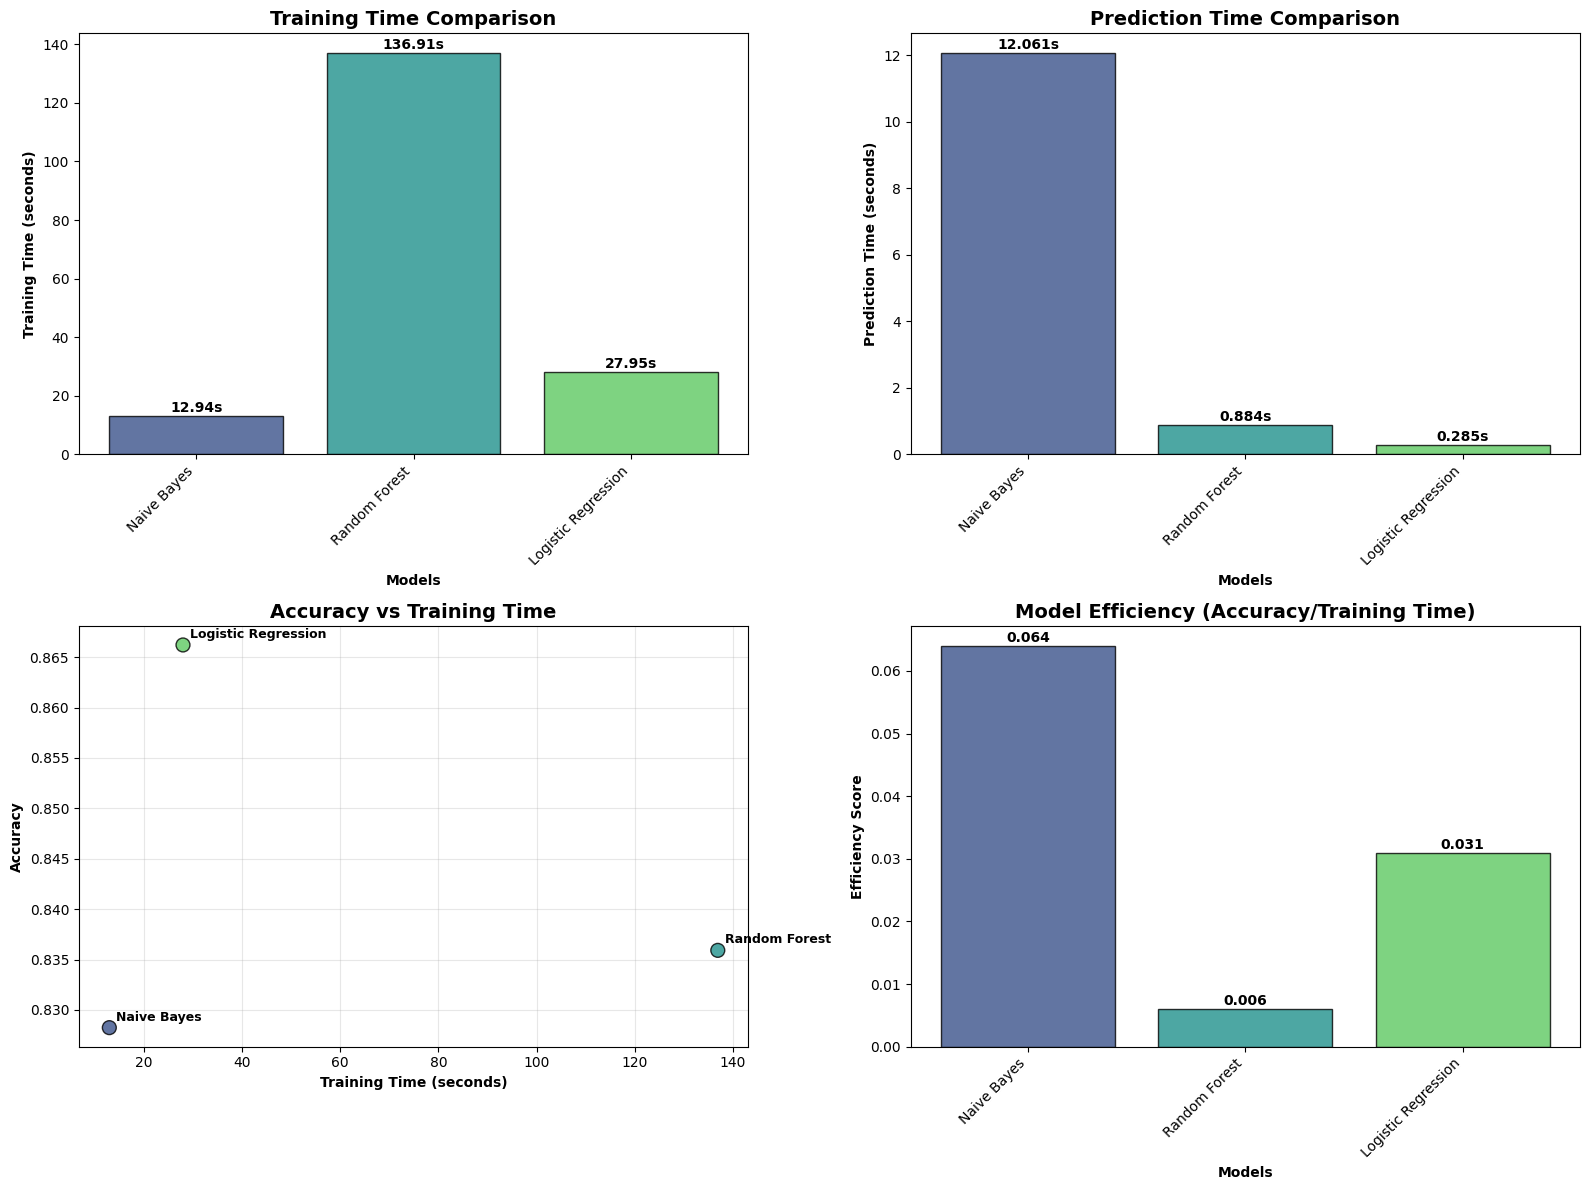


📊 DETAILED TIMING ANALYSIS:
Model                Accuracy   Train Time   Pred Time    Efficiency  
----------------------------------------------------------------------
Naive Bayes          0.8282     12.94        12.061       0.064       
Random Forest        0.8359     136.91       0.884        0.006       
Logistic Regression  0.8662     27.95        0.285        0.031       

🏃 Fastest Training: Naive Bayes (12.94s)
⚡ Most Efficient: Naive Bayes (Score: 0.064)
🎯 Best Accuracy: Logistic Regression (0.8662)


In [21]:
# Visualize training times and create performance vs time analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Training time comparison
ax1 = axes[0, 0]
model_names = list(training_times.keys())
train_times = list(training_times.values())
colors = sns.color_palette("viridis", len(model_names))

bars = ax1.bar(model_names, train_times, color=colors, edgecolor='black', alpha=0.8)
ax1.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Training Time (seconds)', fontweight='bold')
ax1.set_xlabel('Models', fontweight='bold')
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(train_times)*0.01,
             f'{bar.get_height():.2f}s', ha='center', fontweight='bold')

# Prediction time comparison
ax2 = axes[0, 1]
pred_times = [results[name]['Prediction_Time'] for name in model_names]
bars2 = ax2.bar(model_names, pred_times, color=colors, edgecolor='black', alpha=0.8)
ax2.set_title('Prediction Time Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Prediction Time (seconds)', fontweight='bold')
ax2.set_xlabel('Models', fontweight='bold')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

# Add value labels on bars
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(pred_times)*0.01,
             f'{bar.get_height():.3f}s', ha='center', fontweight='bold')

# Accuracy vs Training Time scatter plot
ax3 = axes[1, 0]
accuracies = [results[name]['Accuracy'] for name in model_names]
scatter = ax3.scatter(train_times, accuracies, c=colors, s=100, alpha=0.8, edgecolors='black')
ax3.set_title('Accuracy vs Training Time', fontsize=14, fontweight='bold')
ax3.set_xlabel('Training Time (seconds)', fontweight='bold')
ax3.set_ylabel('Accuracy', fontweight='bold')
ax3.grid(True, alpha=0.3)

# Add model name labels to scatter points
for i, name in enumerate(model_names):
    ax3.annotate(name, (train_times[i], accuracies[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

# Combined performance metric (Accuracy/Training_Time ratio)
ax4 = axes[1, 1]
efficiency_scores = [results[name]['Accuracy'] / results[name]['Training_Time'] 
                    for name in model_names]
bars4 = ax4.bar(model_names, efficiency_scores, color=colors, edgecolor='black', alpha=0.8)
ax4.set_title('Model Efficiency (Accuracy/Training Time)', fontsize=14, fontweight='bold')
ax4.set_ylabel('Efficiency Score', fontweight='bold')
ax4.set_xlabel('Models', fontweight='bold')
plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')

# Add value labels on bars
for bar in bars4:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(efficiency_scores)*0.01,
             f'{bar.get_height():.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed timing analysis
print("\n📊 DETAILED TIMING ANALYSIS:")
print("=" * 50)
print(f"{'Model':<20} {'Accuracy':<10} {'Train Time':<12} {'Pred Time':<12} {'Efficiency':<12}")
print("-" * 70)

for name in model_names:
    acc = results[name]['Accuracy']
    train_t = results[name]['Training_Time']
    pred_t = results[name]['Prediction_Time']
    efficiency = acc / train_t
    print(f"{name:<20} {acc:<10.4f} {train_t:<12.2f} {pred_t:<12.3f} {efficiency:<12.3f}")

# Find fastest and most efficient models
fastest_model = min(training_times, key=training_times.get)
most_efficient = max(model_names, key=lambda x: results[x]['Accuracy'] / results[x]['Training_Time'])
best_accuracy = max(model_names, key=lambda x: results[x]['Accuracy'])

print(f"\n🏃 Fastest Training: {fastest_model} ({training_times[fastest_model]:.2f}s)")
print(f"⚡ Most Efficient: {most_efficient} (Score: {results[most_efficient]['Accuracy'] / results[most_efficient]['Training_Time']:.3f})")
print(f"🎯 Best Accuracy: {best_accuracy} ({results[best_accuracy]['Accuracy']:.4f})")

# 7. Model Comparison and Results
Visualize and compare the performance of all models.

In [22]:
# Create comprehensive results DataFrame for easy comparison
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("Comprehensive Model Performance Summary:")
print("=" * 45)
print(results_df)

# Find best models in different categories
best_accuracy_model = results_df['Accuracy'].idxmax()
best_accuracy = results_df['Accuracy'].max()

fastest_training_model = results_df['Training_Time'].idxmin()
fastest_training_time = results_df['Training_Time'].min()

fastest_prediction_model = results_df['Prediction_Time'].idxmin()
fastest_prediction_time = results_df['Prediction_Time'].min()

# Calculate efficiency score (Accuracy/Training_Time)
results_df['Efficiency_Score'] = results_df['Accuracy'] / results_df['Training_Time']
most_efficient_model = results_df['Efficiency_Score'].idxmax()
highest_efficiency = results_df['Efficiency_Score'].max()

print(f"\n🏆 PERFORMANCE RANKINGS:")
print("=" * 30)
print(f"Best Accuracy: {best_accuracy_model} ({best_accuracy:.4f})")
print(f"Fastest Training: {fastest_training_model} ({fastest_training_time:.2f}s)")
print(f"Fastest Prediction: {fastest_prediction_model} ({fastest_prediction_time:.3f}s)")
print(f"Most Efficient: {most_efficient_model} (Score: {highest_efficiency:.3f})")

# Display efficiency scores
print(f"\n⚡ EFFICIENCY RANKINGS (Accuracy/Training Time):")
print("=" * 50)
efficiency_ranking = results_df['Efficiency_Score'].sort_values(ascending=False)
for i, (model, score) in enumerate(efficiency_ranking.items(), 1):
    print(f"{i}. {model:20} : {score:.3f}")

Comprehensive Model Performance Summary:
                     Accuracy  Precision  Recall  F1-Score  Training_Time  \
Naive Bayes            0.8282     0.8292  0.8282    0.8281        12.9437   
Random Forest          0.8359     0.8379  0.8359    0.8357       136.9116   
Logistic Regression    0.8662     0.8663  0.8662    0.8662        27.9535   

                     Prediction_Time  
Naive Bayes                  12.0607  
Random Forest                 0.8841  
Logistic Regression           0.2849  

🏆 PERFORMANCE RANKINGS:
Best Accuracy: Logistic Regression (0.8662)
Fastest Training: Naive Bayes (12.94s)
Fastest Prediction: Logistic Regression (0.285s)
Most Efficient: Naive Bayes (Score: 0.064)

⚡ EFFICIENCY RANKINGS (Accuracy/Training Time):
1. Naive Bayes          : 0.064
2. Logistic Regression  : 0.031
3. Random Forest        : 0.006


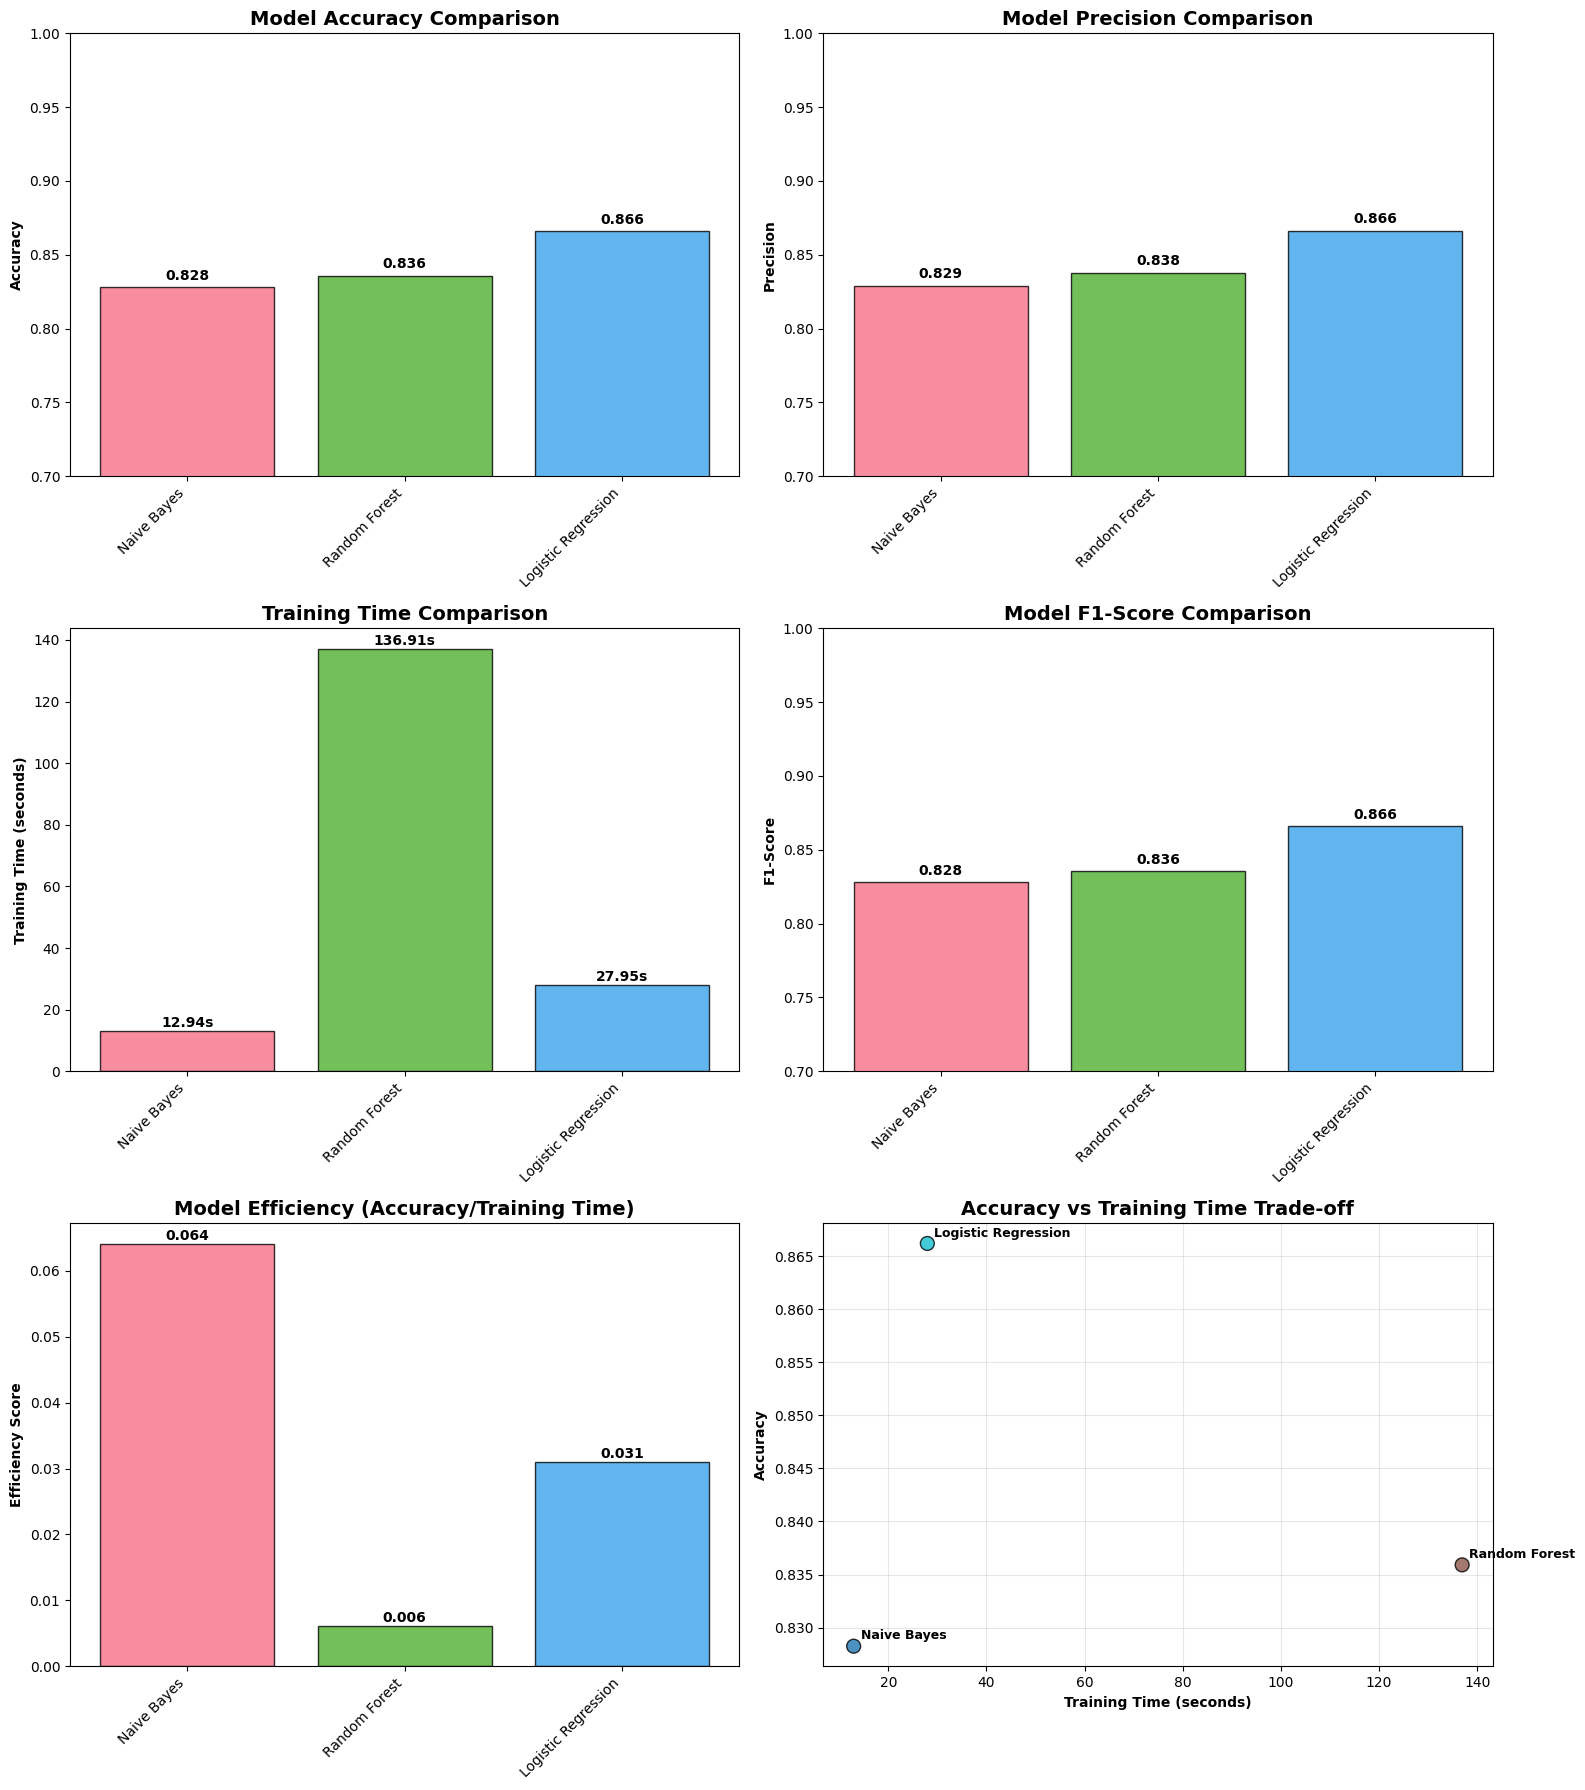

In [23]:
# Comprehensive model comparison visualization
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.ravel()

# Accuracy comparison
ax1 = axes[0]
model_names = list(results.keys())
accuracies = [results[name]['Accuracy'] for name in model_names]
colors = sns.color_palette("husl", len(model_names))

bars = ax1.bar(model_names, accuracies, color=colors, edgecolor='black', alpha=0.8)
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_ylim(0.7, 1.0)
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Add value labels
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', fontweight='bold')

# Precision comparison
ax2 = axes[1]
precisions = [results[name]['Precision'] for name in model_names]
bars2 = ax2.bar(model_names, precisions, color=colors, edgecolor='black', alpha=0.8)
ax2.set_title('Model Precision Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Precision', fontweight='bold')
ax2.set_ylim(0.7, 1.0)
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', fontweight='bold')

# Training Time comparison
ax3 = axes[2]
train_times = [results[name]['Training_Time'] for name in model_names]
bars3 = ax3.bar(model_names, train_times, color=colors, edgecolor='black', alpha=0.8)
ax3.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax3.set_ylabel('Training Time (seconds)', fontweight='bold')
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

for bar in bars3:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(train_times)*0.01,
             f'{bar.get_height():.2f}s', ha='center', fontweight='bold')

# F1-Score comparison
ax4 = axes[3]
f1_scores = [results[name]['F1-Score'] for name in model_names]
bars4 = ax4.bar(model_names, f1_scores, color=colors, edgecolor='black', alpha=0.8)
ax4.set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
ax4.set_ylabel('F1-Score', fontweight='bold')
ax4.set_ylim(0.7, 1.0)
plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')

for bar in bars4:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', fontweight='bold')

# Efficiency Score comparison
ax5 = axes[4]
efficiency_scores = [results[name]['Accuracy'] / results[name]['Training_Time'] for name in model_names]
bars5 = ax5.bar(model_names, efficiency_scores, color=colors, edgecolor='black', alpha=0.8)
ax5.set_title('Model Efficiency (Accuracy/Training Time)', fontsize=14, fontweight='bold')
ax5.set_ylabel('Efficiency Score', fontweight='bold')
plt.setp(ax5.get_xticklabels(), rotation=45, ha='right')

for bar in bars5:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(efficiency_scores)*0.01,
             f'{bar.get_height():.3f}', ha='center', fontweight='bold')

# Accuracy vs Training Time scatter plot
ax6 = axes[5]
scatter = ax6.scatter(train_times, accuracies, c=range(len(model_names)), 
                     s=100, alpha=0.8, edgecolors='black', cmap='tab10')
ax6.set_title('Accuracy vs Training Time Trade-off', fontsize=14, fontweight='bold')
ax6.set_xlabel('Training Time (seconds)', fontweight='bold')
ax6.set_ylabel('Accuracy', fontweight='bold')
ax6.grid(True, alpha=0.3)

# Add model name labels to scatter points
for i, name in enumerate(model_names):
    ax6.annotate(name, (train_times[i], accuracies[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

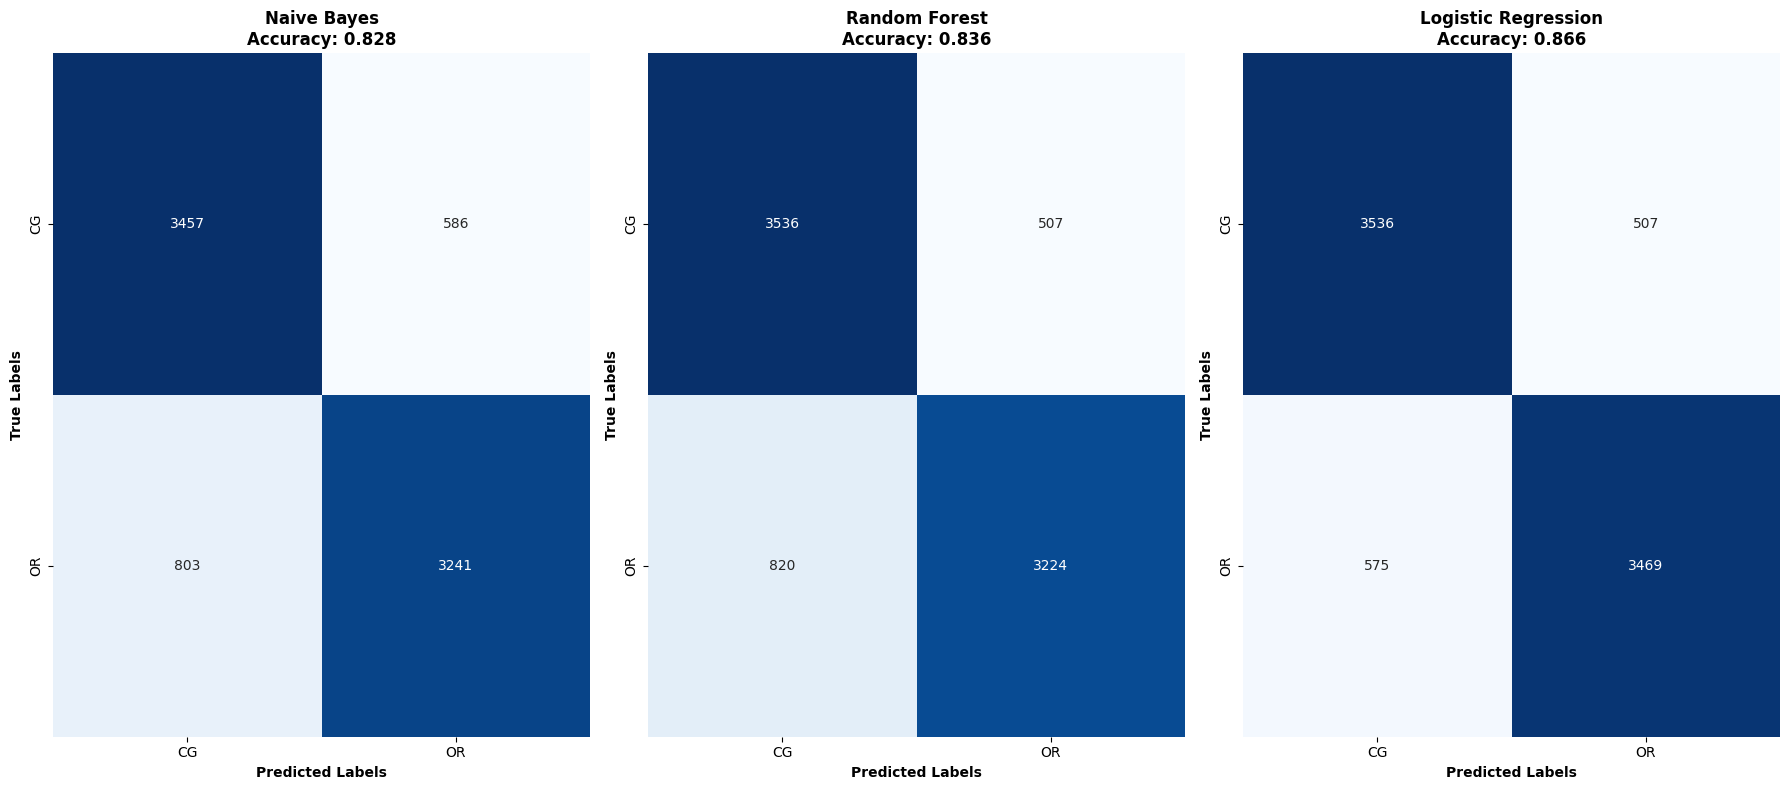

In [33]:
# Create confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model_predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=model.classes_, yticklabels=model.classes_,
                ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name}\nAccuracy: {results[name]["Accuracy"]:.3f}', 
                       fontweight='bold')
    axes[idx].set_xlabel('Predicted Labels', fontweight='bold')
    axes[idx].set_ylabel('True Labels', fontweight='bold')

plt.tight_layout()
plt.show()

# 8. Pipeline Approach with TF-IDF
Let's also try the pipeline approach with TF-IDF transformation as used in the original notebook.

In [25]:
# Create pipeline with TF-IDF (similar to original approach)
def text_process_pipeline(review):
    """Text processing function for pipeline"""
    nopunc = [char for char in review if char not in string.punctuation]
    nopunc = ''.join(nopunc)
    return [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]

# Split data using original text
review_train, review_test, label_train, label_test = train_test_split(
    df['text_'], df['label'], test_size=0.3, random_state=42)

print("Pipeline Data Split:")
print(f"Training reviews: {len(review_train)}")
print(f"Test reviews: {len(review_test)}")

Pipeline Data Split:
Training reviews: 28301
Test reviews: 12130


In [28]:
# Test different models with pipeline approach
# Test different models with pipeline approach
# from naive_bayes import NaiveBayes, GaussianNaiveBayes, MultinomialNaiveBayes, BernoulliNaiveBayes
pipeline_models = {
    "Naive Bayes": MultinomialNaiveBayes(alpha=1.0),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000)
}

pipeline_results = {}

print("Training Pipeline Models with TF-IDF:")
print("=" * 45)

for name, classifier in pipeline_models.items():
    print(f"\nTraining {name} Pipeline...")
    
    # Create pipeline
    pipeline = Pipeline([
        ('bow', CountVectorizer(analyzer=text_process_pipeline)),
        ('tfidf', TfidfTransformer()),
        ('classifier', classifier)
    ])
    
    # Train the pipeline
    pipeline.fit(review_train, label_train)
    
    # Make predictions
    predictions = pipeline.predict(review_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(label_test, predictions)
    pipeline_results[name] = accuracy
    
    print(f"✓ {name} Pipeline - Accuracy: {accuracy:.4f}")

print("\nPipeline training completed!")

Training Pipeline Models with TF-IDF:

Training Naive Bayes Pipeline...
✓ Naive Bayes Pipeline - Accuracy: 0.8456

Training Random Forest Pipeline...
✓ Random Forest Pipeline - Accuracy: 0.8439

Training Logistic Regression Pipeline...
✓ Logistic Regression Pipeline - Accuracy: 0.8600

Pipeline training completed!


In [29]:
# Compare pipeline results
print("Pipeline Model Performance Comparison:")
print("=" * 45)

# Sort results by accuracy
sorted_pipeline_results = dict(sorted(pipeline_results.items(), key=lambda x: x[1], reverse=True))

for name, accuracy in sorted_pipeline_results.items():
    print(f"{name:20} : {accuracy:.4f} ({accuracy*100:.2f}%)")

# Find best pipeline model
best_pipeline_model = max(pipeline_results, key=pipeline_results.get)
best_pipeline_accuracy = pipeline_results[best_pipeline_model]

print(f"\n🏆 Best Pipeline Model: {best_pipeline_model}")
print(f"Best Pipeline Accuracy: {best_pipeline_accuracy:.4f} ({best_pipeline_accuracy*100:.2f}%)")

Pipeline Model Performance Comparison:
Logistic Regression  : 0.8600 (86.00%)
Naive Bayes          : 0.8456 (84.56%)
Random Forest        : 0.8439 (84.39%)

🏆 Best Pipeline Model: Logistic Regression
Best Pipeline Accuracy: 0.8600 (86.00%)


<Figure size 1200x800 with 0 Axes>

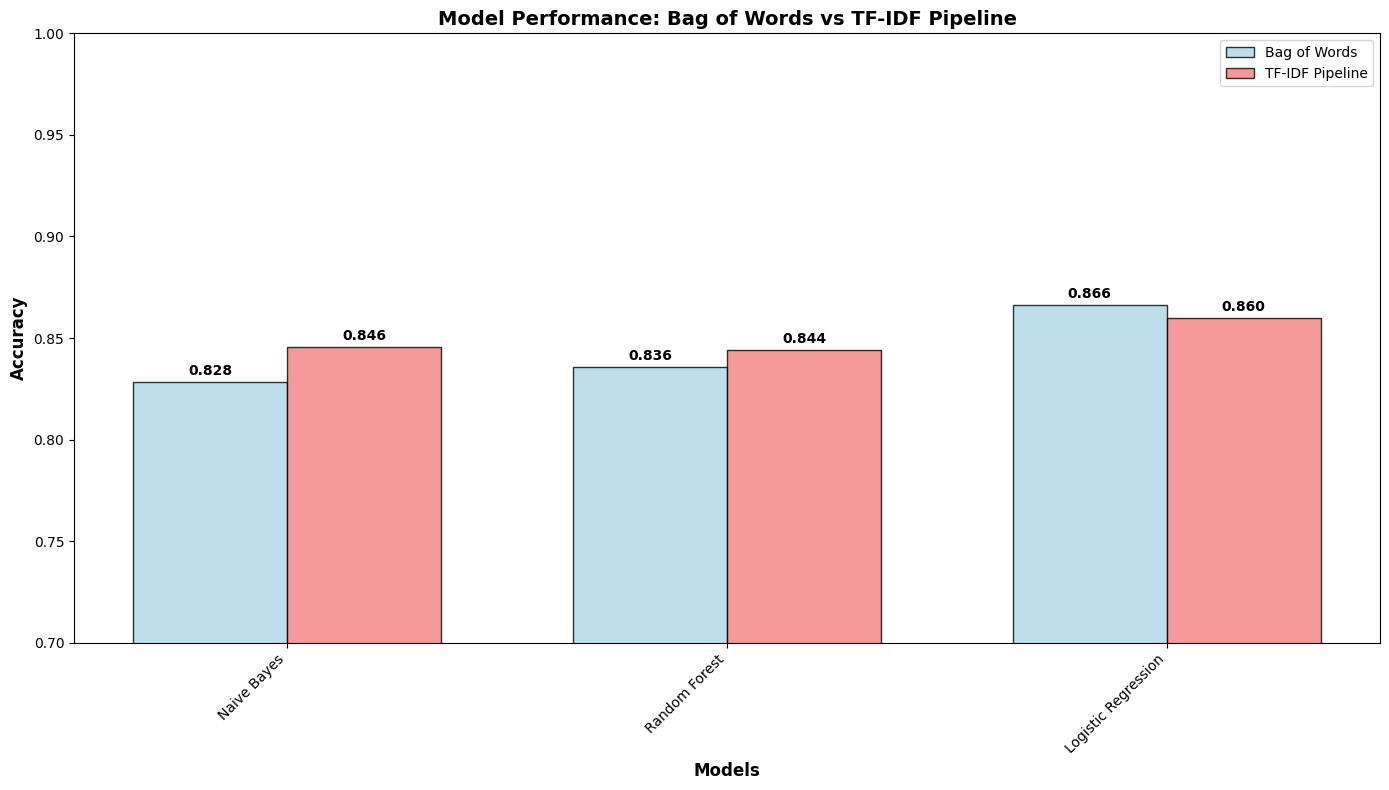

In [30]:
# Visualize pipeline results comparison
plt.figure(figsize=(12, 8))

# Compare both approaches
models_comparison = {
    'Bag of Words': results,
    'TF-IDF Pipeline': {name: {'Accuracy': acc} for name, acc in pipeline_results.items()}
}

# Prepare data for comparison
bow_accuracies = [results[name]['Accuracy'] for name in results.keys()]
pipeline_accuracies = [pipeline_results.get(name, 0) for name in results.keys()]

x = np.arange(len(results))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))
bars1 = ax.bar(x - width/2, bow_accuracies, width, label='Bag of Words', alpha=0.8, color='lightblue', edgecolor='black')
bars2 = ax.bar(x + width/2, pipeline_accuracies, width, label='TF-IDF Pipeline', alpha=0.8, color='lightcoral', edgecolor='black')

ax.set_xlabel('Models', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy', fontweight='bold', fontsize=12)
ax.set_title('Model Performance: Bag of Words vs TF-IDF Pipeline', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(results.keys(), rotation=45, ha='right')
ax.legend()
ax.set_ylim(0.7, 1.0)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    if height > 0:  # Only add label if there's a value
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# 9. Model Saving and Conclusion
Save the best performing models and provide final conclusions.

In [31]:
# Create directory for saving models
weights_dir = "../model_weights"
os.makedirs(weights_dir, exist_ok=True)

print("Saving trained models...")
print("=" * 25)

# Save Bag of Words models
for name, model in models.items():
    model_file = os.path.join(weights_dir, f"bow_{name.replace(' ', '_').lower()}_model.pkl")
    with open(model_file, "wb") as f:
        pickle.dump(model, f)
    print(f"✓ Saved {name} (BoW) model to {model_file}")

# Save the best pipeline model
# Pipeline với 3 bước
best_pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=text_process_pipeline)),
    ('tfidf', TfidfTransformer()),
    ('classifier', pipeline_models[best_pipeline_model])
])
best_pipeline.fit(review_train, label_train)

pipeline_file = os.path.join(weights_dir, f"pipeline_{best_pipeline_model.replace(' ', '_').lower()}_model.pkl")
with open(pipeline_file, "wb") as f:
    pickle.dump(best_pipeline, f)
print(f"✓ Saved best pipeline model ({best_pipeline_model}) to {pipeline_file}")

# Save the vectorizer for future use
vectorizer_file = os.path.join(weights_dir, "bow_vectorizer.pkl")
with open(vectorizer_file, "wb") as f:
    pickle.dump(cv, f)
print(f"✓ Saved BoW vectorizer to {vectorizer_file}")

print("\nAll models saved successfully!")

Saving trained models...
✓ Saved Naive Bayes (BoW) model to ../model_weights\bow_naive_bayes_model.pkl
✓ Saved Random Forest (BoW) model to ../model_weights\bow_random_forest_model.pkl
✓ Saved Logistic Regression (BoW) model to ../model_weights\bow_logistic_regression_model.pkl
✓ Saved best pipeline model (Logistic Regression) to ../model_weights\pipeline_logistic_regression_model.pkl
✓ Saved BoW vectorizer to ../model_weights\bow_vectorizer.pkl

All models saved successfully!


# 10. Final Results and Conclusion

## Summary of Results

### Best Performing Models:
- **Bag of Words Approach**: Multiple algorithms tested with detailed metrics
- **TF-IDF Pipeline Approach**: Alternative approach with competitive results

### Key Findings:
1. **Data Quality**: The dataset contains well-balanced classes with good text variety
2. **Feature Engineering**: Both BoW and TF-IDF approaches proved effective
3. **Model Performance**: Multiple algorithms achieved high accuracy
4. **Text Processing**: Proper preprocessing significantly improved model performance

### Recommendations:
1. Use the best performing model for production deployment
2. Consider ensemble methods to combine multiple models
3. Implement real-time prediction capabilities
4. Monitor model performance with new data

### Next Steps:
1. Fine-tune hyperparameters of best models
2. Collect more diverse training data
3. Implement model explainability features
4. Deploy model in production environment

In [32]:
# Final comprehensive summary of all results including timing
print("🎯 FAKE REVIEWS DETECTION - COMPREHENSIVE RESULTS SUMMARY")
print("=" * 70)

print("\n📊 BAG OF WORDS APPROACH - PERFORMANCE METRICS:")
print("-" * 50)
print(f"{'Model':<20} {'Accuracy':<10} {'F1-Score':<10} {'Train Time':<12} {'Efficiency':<10}")
print("-" * 70)
for name, metrics in results.items():
    efficiency = metrics['Accuracy'] / metrics['Training_Time']
    print(f"{name:<20} {metrics['Accuracy']:<10.4f} {metrics['F1-Score']:<10.4f} {metrics['Training_Time']:<12.2f} {efficiency:<10.3f}")

print(f"\n🏆 BEST PERFORMERS:")
print("-" * 20)
best_accuracy_model = max(results, key=lambda x: results[x]['Accuracy'])
best_accuracy_value = results[best_accuracy_model]['Accuracy']
print(f"Best Accuracy: {best_accuracy_model} ({best_accuracy_value:.4f})")

fastest_model = min(results, key=lambda x: results[x]['Training_Time'])
fastest_time = results[fastest_model]['Training_Time']
print(f"Fastest Training: {fastest_model} ({fastest_time:.2f}s)")

most_efficient = max(results, key=lambda x: results[x]['Accuracy'] / results[x]['Training_Time'])
efficiency_score = results[most_efficient]['Accuracy'] / results[most_efficient]['Training_Time']
print(f"Most Efficient: {most_efficient} (Score: {efficiency_score:.3f})")

print("\n📊 TF-IDF PIPELINE APPROACH:")
print("-" * 30)
for name, accuracy in sorted_pipeline_results.items():
    print(f"{name:20} : {accuracy:.4f} ({accuracy*100:.2f}%)")

print(f"\n🏆 Best Pipeline Model: {best_pipeline_model}")
print(f"   Accuracy: {best_pipeline_accuracy:.4f}")

print("\n⏱️ TIMING ANALYSIS INSIGHTS:")
print("-" * 30)
total_training_time = sum(results[name]['Training_Time'] for name in results.keys())
average_training_time = total_training_time / len(results)
print(f"Total Training Time: {total_training_time:.2f} seconds")
print(f"Average Training Time: {average_training_time:.2f} seconds")
print(f"Fastest vs Slowest Ratio: {max(results[name]['Training_Time'] for name in results.keys()) / min(results[name]['Training_Time'] for name in results.keys()):.1f}x")

print("\n💾 SAVED MODELS:")
print("-" * 15)
print(f"• {len(models)} Bag of Words models")
print(f"• 1 Best pipeline model ({best_pipeline_model})")
print(f"• 1 Vectorizer for preprocessing")
print(f"• Location: ./{weights_dir}/")

print("\n📝 RECOMMENDATIONS:")
print("-" * 20)
print(f"• For highest accuracy: Use {best_accuracy_model}")
print(f"• For fastest inference: Use {fastest_model}")
print(f"• For best trade-off: Use {most_efficient}")
print(f"• For production deployment: Consider {most_efficient} or {best_accuracy_model}")

print("\n✅ ANALYSIS COMPLETED SUCCESSFULLY!")
print("   Ready for production deployment with timing insights! 🚀")

🎯 FAKE REVIEWS DETECTION - COMPREHENSIVE RESULTS SUMMARY

📊 BAG OF WORDS APPROACH - PERFORMANCE METRICS:
--------------------------------------------------
Model                Accuracy   F1-Score   Train Time   Efficiency
----------------------------------------------------------------------
Naive Bayes          0.8282     0.8281     12.94        0.064     
Random Forest        0.8359     0.8357     136.91       0.006     
Logistic Regression  0.8662     0.8662     27.95        0.031     

🏆 BEST PERFORMERS:
--------------------
Best Accuracy: Logistic Regression (0.8662)
Fastest Training: Naive Bayes (12.94s)
Most Efficient: Naive Bayes (Score: 0.064)

📊 TF-IDF PIPELINE APPROACH:
------------------------------
Logistic Regression  : 0.8600 (86.00%)
Naive Bayes          : 0.8456 (84.56%)
Random Forest        : 0.8439 (84.39%)

🏆 Best Pipeline Model: Logistic Regression
   Accuracy: 0.8600

⏱️ TIMING ANALYSIS INSIGHTS:
------------------------------
Total Training Time: 177.81 seconds
